Importing the dependencies

In [ ]:
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

In [ ]:
!pip install opendatasets
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import time
import opendatasets as od
import os


Load Dataset

In [ ]:
od.download('https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: KGAT_dfc6a9f1b89eceb39901b8189624142a
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset


100%|██████████| 2.04G/2.04G [00:14<00:00, 149MB/s]


In [ ]:
# what folers inside my dataset
print(os.listdir("/content/plantvillage-dataset"))

['plantvillage dataset']


In [ ]:
print(os.listdir('/content/plantvillage-dataset/plantvillage dataset'))

['color', 'segmented', 'grayscale']


In [ ]:
'''Counts how many classes (folders) are in color
Shows first 5 folder names'''

print(len(os.listdir('/content/plantvillage-dataset/plantvillage dataset/color')))
print(os.listdir("/content/plantvillage-dataset/plantvillage dataset/color")[:5])

38
['Corn_(maize)___Common_rust_', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Strawberry___Leaf_scorch', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Orange___Haunglongbing_(Citrus_greening)']


In [ ]:
print(len(os.listdir("/content/plantvillage-dataset/plantvillage dataset/segmented")))
print(os.listdir("/content/plantvillage-dataset/plantvillage dataset/segmented")[:5])

38
['Corn_(maize)___Common_rust_', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Strawberry___Leaf_scorch', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Orange___Haunglongbing_(Citrus_greening)']


In [ ]:
print(len(os.listdir("/content/plantvillage-dataset/plantvillage dataset/grayscale")))
print(os.listdir("/content/plantvillage-dataset/plantvillage dataset/grayscale")[:5])

38
['Corn_(maize)___Common_rust_', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Strawberry___Leaf_scorch', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Orange___Haunglongbing_(Citrus_greening)']


 Prepare & Preprocess Images

In [ ]:
# We will use COLOR folder (best for CNN)
data_dir = "/content/plantvillage-dataset/plantvillage dataset/color"

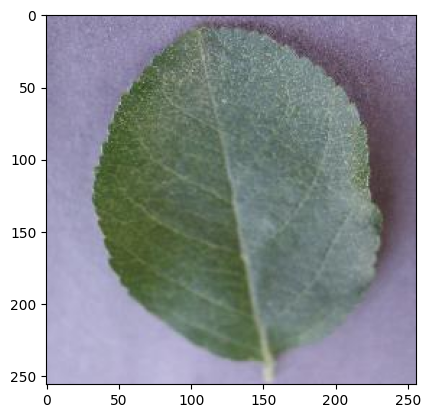

In [ ]:
import matplotlib.image as mpimg
image_path = '/content/plantvillage-dataset/plantvillage dataset/color/Apple___healthy/00a6039c-e425-4f7d-81b1-d6b0e668517e___RS_HL 7669.JPG'

img = mpimg.imread(image_path)
plt.imshow(img)

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 20

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Collect all file paths and labels
all_images = []
all_labels = []

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        for img_file in os.listdir(class_path):
            all_images.append(os.path.join(class_path, img_file))
            all_labels.append(class_name)

print(f"Total images: {len(all_images)}")

#  Split 80 / 10 / 10
# First cut → 80% train, 20% temp
train_imgs, temp_imgs, train_lbls, temp_lbls = train_test_split(
    all_images, all_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_labels        # keeps class balance
)

# Second cut → 10% val, 10% test
val_imgs, test_imgs, val_lbls, test_lbls = train_test_split(
    temp_imgs, temp_lbls,
    test_size=0.5,
    random_state=42,
    stratify=temp_lbls
)

print(f"Train : {len(train_imgs)} images")   # ~80%
print(f"Val   : {len(val_imgs)}  images")    # ~10%
print(f"Test  : {len(test_imgs)} images")    # ~10%


#  Copy into new folder structure
def copy_images(img_paths, labels, split_name, base='split_data'):
    for img_path, label in zip(img_paths, labels):
        dest_folder = os.path.join(base, split_name, label)
        os.makedirs(dest_folder, exist_ok=True)
        shutil.copy(img_path, dest_folder)

print("Copying files... (takes a few minutes)")
copy_images(train_imgs, train_lbls, 'train')
copy_images(val_imgs,   val_lbls,   'val')
copy_images(test_imgs,  test_lbls,  'test')
print("Done! ✅")




Total images: 54305
Train : 43444 images
Val   : 5430  images
Test  : 5431 images
Copying files... (takes a few minutes)
Done! ✅


Create Image Data Generators & split data

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

# Val & Test → NO augmentation (only rescale)
test_datagen = ImageDataGenerator(rescale=1./255)


# Load train
train_data = train_datagen.flow_from_directory(
    '/content/split_data/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42
)

# Load val
val_data = test_datagen.flow_from_directory(
    '/content/split_data/val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed = 42
)

# Load test
test_data = test_datagen.flow_from_directory(
    '/content/split_data/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False              # ✅ important for evaluation!
)

print(f"\nTrain : {train_data.samples}")
print(f"Val   : {val_data.samples}")
print(f"Test  : {test_data.samples}")

Found 43444 images belonging to 38 classes.
Found 5430 images belonging to 38 classes.
Found 5431 images belonging to 38 classes.

Train : 43444
Val   : 5430
Test  : 5431


Visualize Sample Images

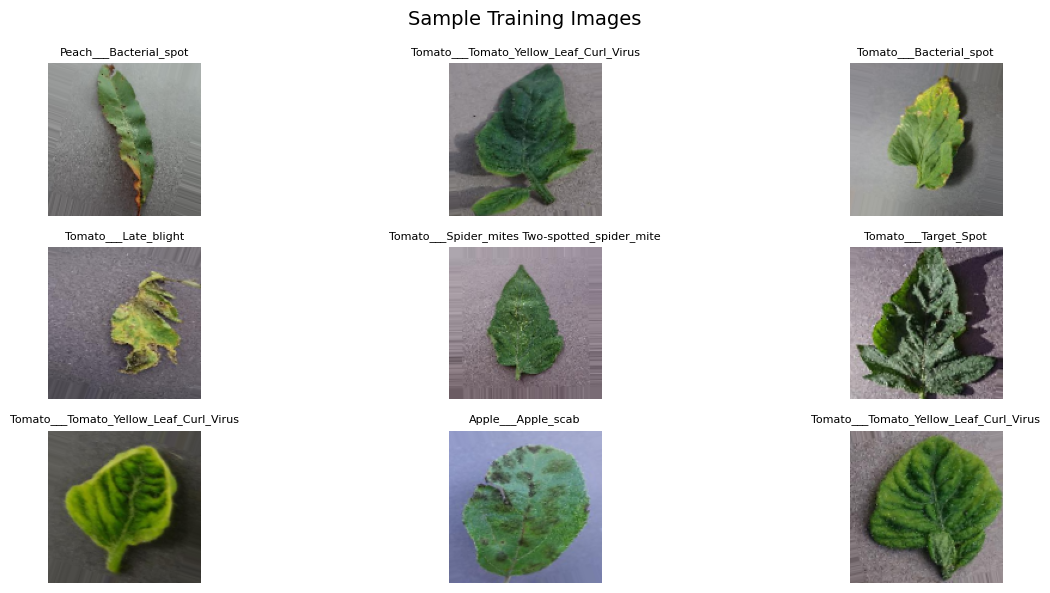

In [ ]:
images, labels = next(train_data)
class_names = list(train_data.class_indices.keys())

plt.figure(figsize=(14, 6))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    label_index = np.argmax(labels[i])
    plt.title(class_names[label_index], fontsize=8)
    plt.axis('off')
plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ✅ CORRECT WAY - for ImageDataGenerator
images, labels = next(iter(train_data))

print(f"Image batch shape : {images.shape}")
print(f"Label batch shape : {labels.shape}")
print(f"Min pixel value   : {images.min():.2f}")
print(f"Max pixel value   : {images.max():.2f}")
print(f"Total classes     : {labels.shape[1]}")

Image batch shape : (32, 128, 128, 3)
Label batch shape : (32, 38)
Min pixel value   : 0.00
Max pixel value   : 1.00
Total classes     : 38


Build CNN Model

In [ ]:
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dense, Dropout

num_classes = len(train_data.class_indices)  # 38

model = tf.keras.models.Sequential([

    #  Block 1 - finds basic edges
    Conv2D(32, (3,3), activation='relu',
           input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    #  Block 2 - finds shapes
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    #  Block 3 - finds spots/lesions
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # ── Block 4 - finds complex patterns
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    #  Classify
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.3),    # prevents overfitting

    Dense(256, activation='relu'),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')  # 38 outputs
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,250,534 (20.03 MB)

 Trainable params: 5,249,574 (20.03 MB)

 Non-trainable params: 960 (3.75 KB)

Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Train Model

In [ ]:
start_time = time.time()

history = model.fit(train_data,
                    epochs=EPOCHS,
                    validation_data=val_data
)

end_time = time.time()

Epoch 1/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 247s 173ms/step - accuracy: 0.6087 - loss: 1.4710 - val_accuracy: 0.5026 - val_loss: 1.8614
Epoch 2/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 222s 164ms/step - accuracy: 0.7791 - loss: 0.7474 - val_accuracy: 0.7368 - val_loss: 0.9306
Epoch 3/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 224s 165ms/step - accuracy: 0.8388 - loss: 0.5411 - val_accuracy: 0.7652 - val_loss: 1.0186
Epoch 4/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 219s 161ms/step - accuracy: 0.8707 - loss: 0.4393 - val_accuracy: 0.6983 - val_loss: 1.4357
Epoch 5/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 221s 163ms/step - accuracy: 0.8904 - loss: 0.3773 - val_accuracy: 0.8510 - val_loss: 0.5028
Epoch 6/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 219s 161ms/step - accuracy: 0.9069 - loss: 0.3209 - val_accuracy: 0.8611 - val_loss: 0.5966
Epoch 7/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 220s 162ms/step - accuracy: 0.9179 - loss: 0.2864 - val_accuracy: 0.8438 - val_loss: 0.5719
Epoch 8/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 222s 164ms/step - ac

 Plot Training Results

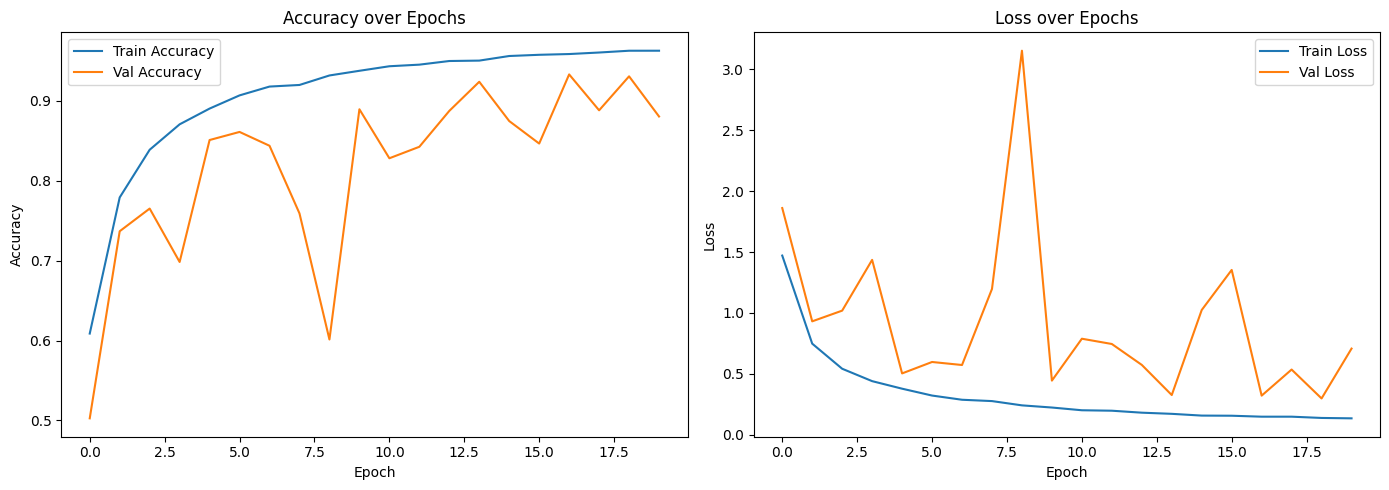

In [ ]:
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Evaluate on Test Set

In [ ]:
model.save('best_model.h5')

# Load best saved model
model = tf.keras.models.load_model('best_model.h5')

# TRUE accuracy on unseen test data
test_loss, test_acc = model.evaluate(test_data)
print(f"\nTest Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

170/170 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.8818 - loss: 0.7059

Test Accuracy : 88.18%
Test Loss     : 0.7059


In [ ]:
# Save immediately before Colab disconnects!
model.save('plant_disease_model.h5')
print("Model saved! ✅")

# Download to your computer!
from google.colab import files
files.download('plant_disease_model.h5')

Model saved! ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Detailed Report + Confusion Matrix

170/170 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.60      0.75        63
                                 Apple___Black_rot       0.89      0.94      0.91        62
                          Apple___Cedar_apple_rust       0.90      0.96      0.93        27
                                   Apple___healthy       0.86      0.90      0.88       165
                               Blueberry___healthy       0.95      0.88      0.91       150
          Cherry_(including_sour)___Powdery_mildew       0.99      0.94      0.97       105
                 Cherry_(including_sour)___healthy       0.99      0.94      0.96        85
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.57      0.94      0.71        51
                       Corn_(maize)___Common_rust_       0.94      1.00      0.97       120
               Corn_(maize)___Norther

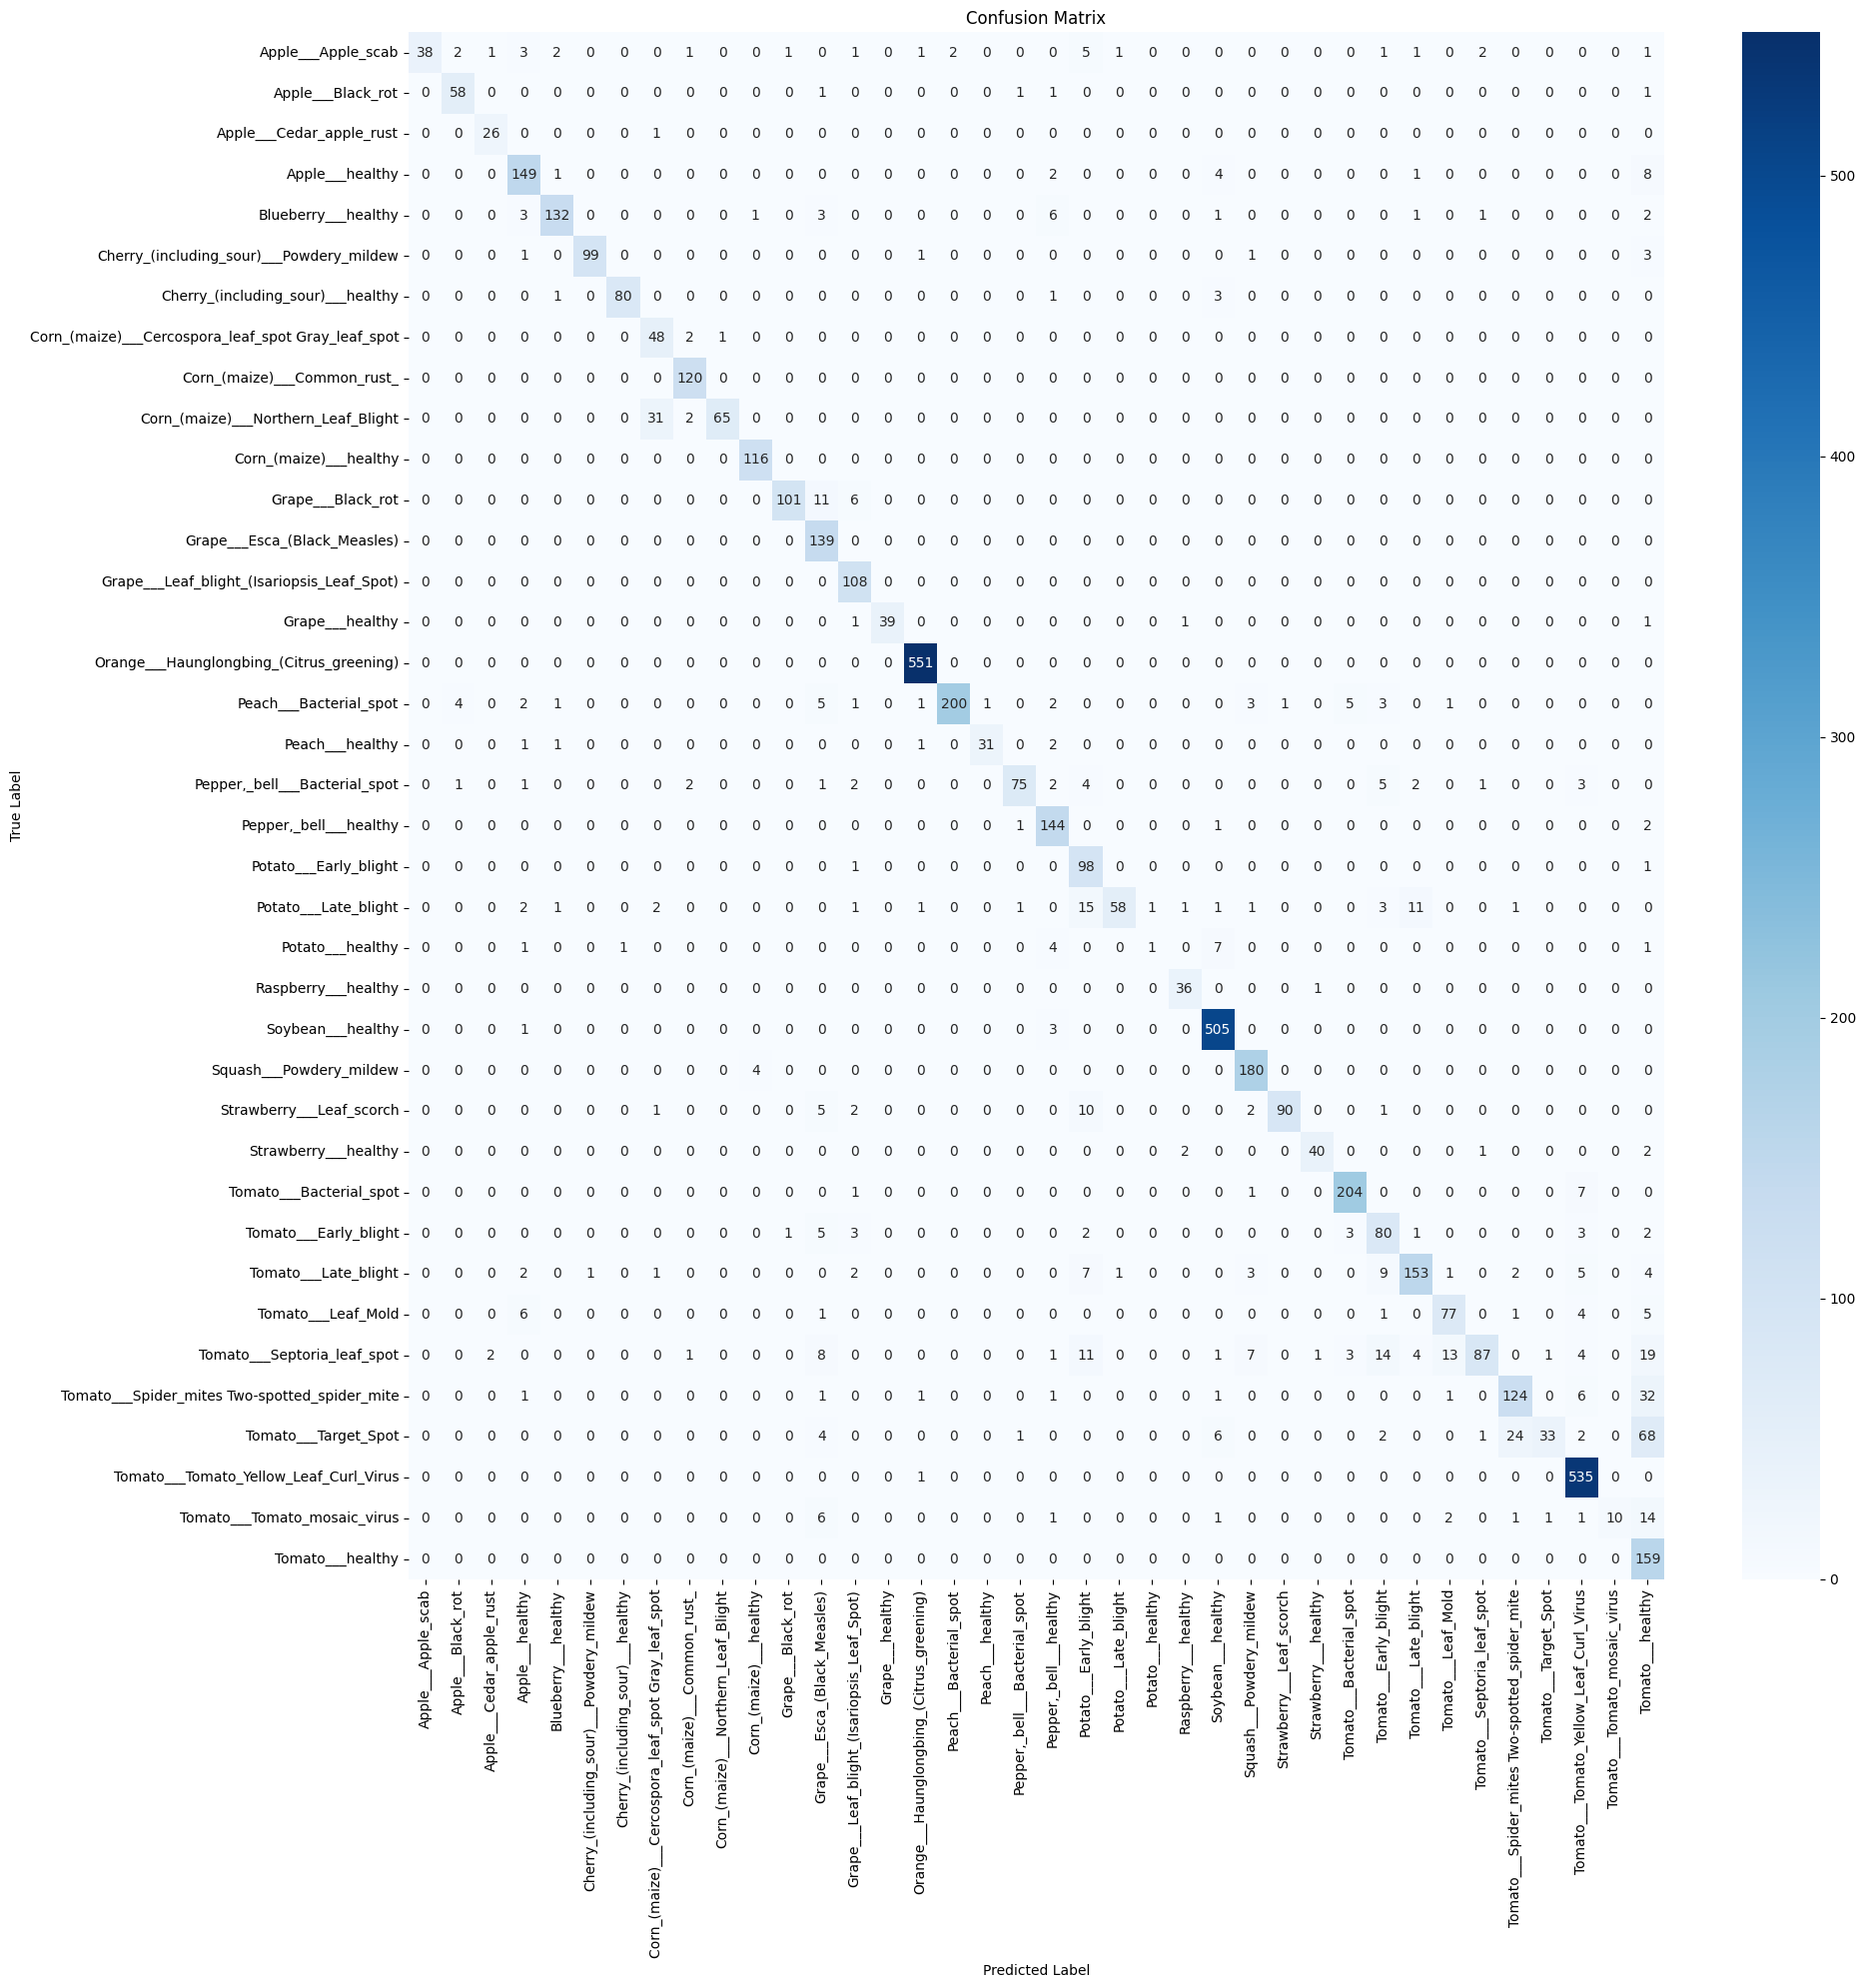

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict all test images
test_data.reset()
preds = model.predict(test_data)
pred_classes = np.argmax(preds, axis=1)
true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

# Per class report
print(classification_report(
    true_classes, pred_classes,
    target_names=class_labels
))

# Confusion matrix
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

Predict a New Leaf Image

In [ ]:
from tensorflow.keras.preprocessing import image

def predict_disease(img_path):
    # Load and preprocess
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)
    predicted_class = class_labels[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    # Show result
    plt.imshow(img)
    plt.title(f"Disease : {predicted_class}\nConfidence : {confidence:.1f}%")
    plt.axis('off')
    plt.show()

    print(f"Disease    : {predicted_class}")
    print(f"Confidence : {confidence:.2f}%")

# Use it!
predict_disease("/content/drive/MyDrive/download.jpg")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')